# Ejercicio 1: Predicción del precio del dólar

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

## 1. Carga de datos

In [2]:
df = pd.read_csv('dolar_data.csv')
df.head()

,Dia,Inflacion,Tasa_interes,Precio_Dolar
0,1,0.022484,5.463089,4024.833598
1,2,0.019309,5.954708,4000.546337
2,3,0.023238,4.300716,3979.622045
3,4,0.027615,5.281485,3940.361345
4,5,0.018829,4.674679,4016.930225


In [3]:
df.describe()

,Dia,Inflacion,Tasa_interes,Precio_Dolar
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,0.020034,5.015913,5211.771934
std,144.481833,0.004906,0.488999,723.895212
min,1.000000,0.003794,3.651557,3940.361345
25%,125.750000,0.016498,4.702354,4604.884954
50%,250.500000,0.020064,5.014266,5218.791143
75%,375.250000,0.023184,5.325621,5825.235279
max,500.000000,0.039264,6.316191,6553.598583


## Verificación de calidad de datos

In [4]:
print('Valores nulos por columna:')
print(df.isnull().sum())
print('Filas duplicadas:', df.duplicated().sum())


Valores nulos por columna:
Dia             0
Inflacion       0
Tasa_interes    0
Precio_Dolar    0
dtype: int64
Filas duplicadas: 0


## 2. Entrenamiento del modelo

In [5]:
X = df[['Dia', 'Inflacion', 'Tasa_interes']]
y = df['Precio_Dolar']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 4.98,-870.73, -1.38]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Dia','Inflacion','Tasa_interes']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3986
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


## 3. Interpretación de coeficientes

In [6]:
for var, coef in zip(X.columns, model.coef_):
    print(f'{var}: {coef:.4f}')
print('Intercepto:', model.intercept_)

Dia: 4.9843
Inflacion: -870.7317
Tasa_interes: -1.3774
Intercepto: 3985.7832908942446


Cada coeficiente indica cuánto cambia `Precio_Dolar` cuando esa variable
aumenta en 1 unidad, manteniendo las demás constantes.

## 4. Evaluación del modelo

In [7]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'MSE: {mse:.4f}')
print(f'R2: {r2:.4f}')

MSE: 2376.9709
R2: 0.9963


## 5. Relación de cada variable con el precio del dólar

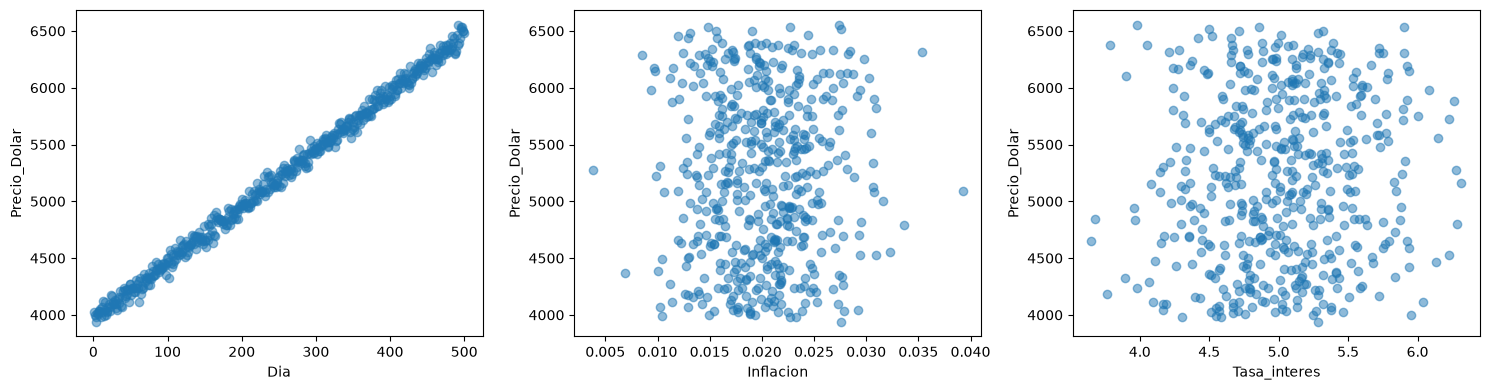

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, X.columns):
    ax.scatter(df[col], df['Precio_Dolar'], alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Precio_Dolar')
plt.tight_layout()
plt.show()

## 6. Exportar modelo

In [9]:
joblib.dump(model, 'modelo_dolar.joblib')

['modelo_dolar.joblib']